In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import boxcox1p
from scipy.stats import skew
from sklearn.preprocessing import LabelEncoder
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅')

✅


In [2]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')

train_id = train['Id']
test_id  = test['Id']
y = np.log1p(train['SalePrice'])  # log-tr

train.drop(columns=['Id', 'SalePrice'], inplace=True)
test.drop(columns=['Id'], inplace=True)

print(f'\ntarget y (log1p): min={y.min():.3f}, max={y.max():.3f}, mean={y.mean():.3f}')

Train: (1460, 81)
Test:  (1459, 80)

target y (log1p): min=10.460, max=13.534, mean=12.024


In [3]:
outlier_mask = (train['GrLivArea'] > 4000) & (np.expm1(y) < 300000)
print(f'Ourliers to delete: {outlier_mask.sum()}')

train = train[~outlier_mask].reset_index(drop=True)
y     = y[~outlier_mask].reset_index(drop=True)

print(f'Train after deleting: {train.shape}')

Ourliers to delete: 2
Train after deleting: (1458, 79)


In [4]:
ntrain = len(train)
all_data = pd.concat([train, test], axis=0, ignore_index=True)

print(f'Combined dataset: {all_data.shape}')
print(f'Train part: lines 0 — {ntrain-1}')
print(f'Test  part: lines {ntrain} — {len(all_data)-1}')

Combined dataset: (2917, 79)
Train part: lines 0 — 1457
Test  part: lines 1458 — 2916


In [5]:
none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

print(f'"None" filled: {len(none_cols)} columns')

"None" filled: 15 columns


In [6]:
zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath',
    'MasVnrArea'
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

print(f'Filled with zeros: {len(zero_cols)} columns')

Filled with zeros: 10 columns


In [7]:
all_data['LotFrontage'] = (
    all_data.groupby('Neighborhood')['LotFrontage']
    .transform(lambda x: x.fillna(x.median()))
)
print('LotFrontage filled with the median by Neighborhood')

LotFrontage filled with the median by Neighborhood


In [8]:
mode_cols = [
    'MSZoning', 'Electrical', 'KitchenQual',
    'Exterior1st', 'Exterior2nd', 'SaleType',
    'Functional'
]
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f'Filled with mode: {len(mode_cols)} columns')

Filled with mode: 7 columns


In [9]:
all_data.drop(columns=['Utilities'], inplace=True)
print('Column Utilities removed (almost a constant)')

# Check
remaining = all_data.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print('No more missing data')
else:
    print('missing data')
    print(remaining)

Column Utilities removed (almost a constant)
No more missing data


In [10]:
cat_as_str = ['MSSubClass', 'OverallCond', 'YrSold', 'MoSold']
for col in cat_as_str:
    all_data[col] = all_data[col].astype(str)

print(f'Сonverted to lines: {cat_as_str}')

Сonverted to lines: ['MSSubClass', 'OverallCond', 'YrSold', 'MoSold']


In [11]:
# New features 
all_data['TotalSF'] = (
    all_data['TotalBsmtSF'] +
    all_data['1stFlrSF'] +
    all_data['2ndFlrSF']
)

all_data['TotalPorchSF'] = (
    all_data['OpenPorchSF'] +
    all_data['EnclosedPorch'] +
    all_data['3SsnPorch'] +
    all_data['ScreenPorch']
)

print('Living space features: TotalSF, TotalPorchSF')

Living space features: TotalSF, TotalPorchSF


In [12]:
all_data['TotalBath'] = (
    all_data['FullBath'] +
    0.5 * all_data['HalfBath'] +
    all_data['BsmtFullBath'] +
    0.5 * all_data['BsmtHalfBath']
)

print(' Bathrooms: TotalBath')

 Bathrooms: TotalBath


In [13]:
# ── Object age ───────────────────────────────────────────────────────
all_data['YrSold_num'] = all_data['YrSold'].astype(int)

all_data['HouseAge']  = all_data['YrSold_num'] - all_data['YearBuilt']
all_data['RemodAge']  = all_data['YrSold_num'] - all_data['YearRemodAdd']
all_data['GarageAge'] = all_data['YrSold_num'] - all_data['GarageYrBlt']
all_data['GarageAge'] = all_data['GarageAge'].clip(lower=0)  # without garage = 0

all_data['IsRemodeled'] = (all_data['YearBuilt'] != all_data['YearRemodAdd']).astype(int)
all_data['IsNew']       = (all_data['YearBuilt'] == all_data['YrSold_num']).astype(int)

all_data.drop(columns=['YrSold_num'], inplace=True)

print('Age: HouseAge, RemodAge, GarageAge, IsRemodeled, IsNew')

Age: HouseAge, RemodAge, GarageAge, IsRemodeled, IsNew


In [14]:
# ── Bin flags ────────────────────────────────────────────────────────
all_data['HasPool']      = (all_data['PoolArea']   > 0).astype(int)
all_data['HasGarage']    = (all_data['GarageArea'] > 0).astype(int)
all_data['HasBsmt']      = (all_data['TotalBsmtSF'] > 0).astype(int)
all_data['HasFireplace'] = (all_data['Fireplaces'] > 0).astype(int)
all_data['Has2ndFloor']  = (all_data['2ndFlrSF']   > 0).astype(int)

print('Flags HasPool, HasGarage, HasBsmt, HasFireplace, Has2ndFloor')

Flags HasPool, HasGarage, HasBsmt, HasFireplace, Has2ndFloor


In [15]:
all_data['OverallQual_TotalSF']    = all_data['OverallQual'] * all_data['TotalSF']
all_data['OverallQual_GrLivArea']  = all_data['OverallQual'] * all_data['GrLivArea']
all_data['OverallQual_TotalBath']  = all_data['OverallQual'] * all_data['TotalBath']

print('Interactions: OverallQual × TotalSF, GrLivArea, TotalBath')

Interactions: OverallQual × TotalSF, GrLivArea, TotalBath


In [16]:
# Final list of features
new_features = [
    'TotalSF', 'TotalPorchSF', 'TotalBath',
    'HouseAge', 'RemodAge', 'GarageAge',
    'IsRemodeled', 'IsNew',
    'HasPool', 'HasGarage', 'HasBsmt', 'HasFireplace', 'Has2ndFloor',
    'OverallQual_TotalSF', 'OverallQual_GrLivArea', 'OverallQual_TotalBath'
]
print(f'Amount of new features: {len(new_features)}')
print(f'Size of dataset: {all_data.shape}')

Amount of new features: 16
Size of dataset: (2917, 94)


In [17]:
# Ordinal categories with a clear meaning (worse → better)
ordinal_maps = {
    'ExterQual':   {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'ExterCond':   {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtQual':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtCond':    {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'BsmtExposure':{'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
    'BsmtFinType1':{'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'BsmtFinType2':{'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
    'HeatingQC':   {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'KitchenQual': {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'FireplaceQu': {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageQual':  {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageCond':  {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5},
    'GarageFinish':{'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
    'PoolQC':      {'None': 0, 'Fa': 1, 'TA': 2, 'Gd': 3, 'Ex': 4},
    'Fence':       {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
    'LandSlope':   {'Sev': 1, 'Mod': 2, 'Gtl': 3},
    'LotShape':    {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4},
    'PavedDrive':  {'N': 0, 'P': 1, 'Y': 2},
    'Functional':  {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4,
                    'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
}

for col, mapping in ordinal_maps.items():
    if col in all_data.columns:
        all_data[col] = all_data[col].map(mapping)

print(f'Ordinal encoding has been applied to {len(ordinal_maps)} columns')

Ordinal encoding has been applied to 19 columns


In [18]:
# Label encoding for other categories with a small number of values
# (those where there is no explicit order, but not too many unique values)
cat_cols = all_data.select_dtypes(include=['object']).columns.tolist()
print(f'Cat columns for label encoding: {len(cat_cols)}')
print(cat_cols)

le = LabelEncoder()
for col in cat_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print('\nLabel Encoding applied')

Cat columns for label encoding: 27
['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition']

Label Encoding applied


In [19]:
# Identify numerical features with high asymmetry
num_features = all_data.select_dtypes(include=[np.number]).columns.tolist()
skew_values  = all_data[num_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

skewed_feats = skew_values[abs(skew_values) > 0.75].index.tolist()
print(f'Features with |skew| > 0.75: {len(skewed_feats)}')

Features with |skew| > 0.75: 59


In [20]:
# We apply the Box-Cox transformation (λ=0.15—the standard choice for this dataset)
lam = 0.15

for feat in skewed_feats:
    all_data[feat] = boxcox1p(all_data[feat], lam)

print(f'Box-Cox (λ={lam}) applied to the {len(skewed_feats)} features')

# Checking result
skew_after = all_data[skewed_feats].apply(lambda x: skew(x.dropna()))
still_skewed = (abs(skew_after) > 0.75).sum()
print(f'More that were cut down after the transformation: {still_skewed}')

Box-Cox (λ=0.15) applied to the 59 features
More that were cut down after the transformation: 42


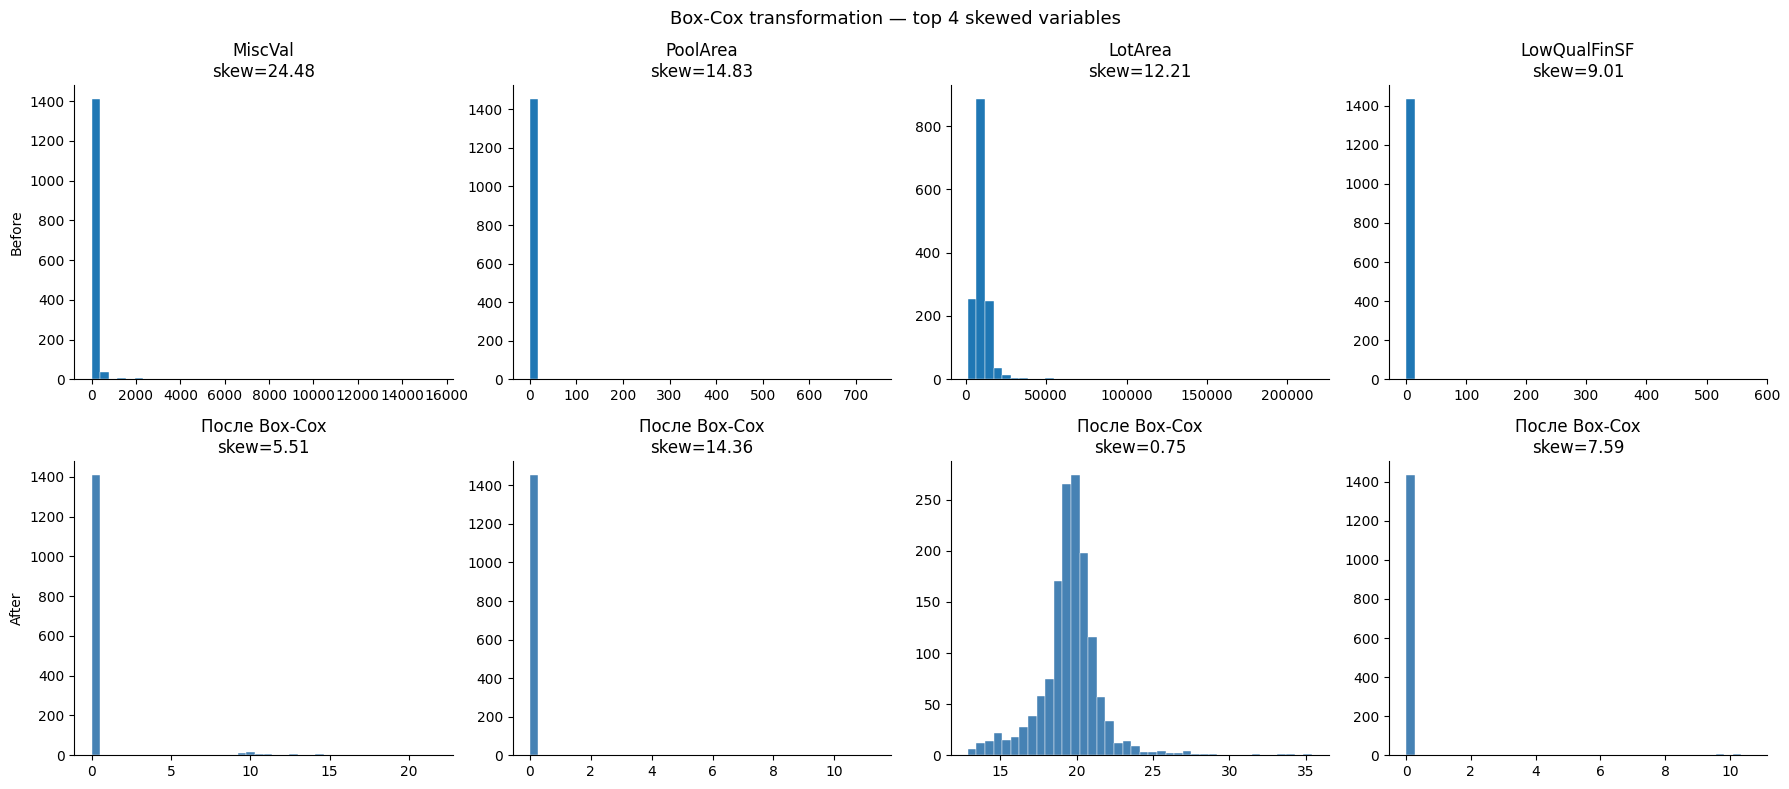

In [21]:
# Before-and-after visualization for the top 4 slanted features
top_skewed = skew_values.head(4).index.tolist()

# Reset the original values for comparison
train_orig = pd.read_csv('data/train.csv')

numeric_orig = train_orig.select_dtypes(include=[np.number]).columns.tolist()
top_skewed_viz = [f for f in skew_values.head(10).index if f in numeric_orig][:4]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, feat in enumerate(top_skewed_viz):
    axes[0, i].hist(train_orig[feat].dropna(), bins=40, edgecolor='white', linewidth=0.3)
    axes[0, i].set_title(f'{feat}\nskew={train_orig[feat].skew():.2f}')
    axes[0, i].set_ylabel('Before' if i == 0 else '')

    transformed = boxcox1p(train_orig[feat].fillna(0), lam)
    axes[1, i].hist(transformed, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[1, i].set_title(f'После Box-Cox\nskew={skew(transformed):.2f}')
    axes[1, i].set_ylabel('After' if i == 0 else '')

plt.suptitle('Box-Cox transformation — top 4 skewed variables', fontsize=13)
plt.tight_layout()
plt.show()

In [22]:
cat_remaining = all_data.select_dtypes(include=['object']).columns.tolist()
print(f'Category columns after LabelEncoding: {len(cat_remaining)}')
print(f'All numeric columns : {len(cat_remaining) == 0}')
print(f'Total amount: {all_data.shape}')

Category columns after LabelEncoding: 0
All numeric columns : True
Total amount: (2917, 94)


In [23]:
# Split train and test
X_train = all_data.iloc[:ntrain, :].copy()
X_test  = all_data.iloc[ntrain:, :].copy()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y (train): {y.shape}')

# Missing check
assert X_train.isnull().sum().sum() == 0, 'Missing in X_train!'
assert X_test.isnull().sum().sum()  == 0, 'Missing in X_test!'
print('\nNo missing data')

X_train: (1458, 94)
X_test:  (1459, 94)
y (train): (1458,)

No missing data


Top 20 features based on correlation with log(SalePrice):
OverallQual_TotalSF      0.894
OverallQual_GrLivArea    0.856
OverallQual_TotalBath    0.826
TotalSF                  0.823
OverallQual              0.821
GrLivArea                0.738
ExterQual                0.681
GarageCars               0.681
TotalBath                0.677
KitchenQual              0.670
GarageArea               0.656
TotalBsmtSF              0.648
1stFlrSF                 0.618
GarageFinish             0.606
FullBath                 0.596
HouseAge                 0.588
YearBuilt                0.587
GarageAge                0.579
RemodAge                 0.569
YearRemodAdd             0.566


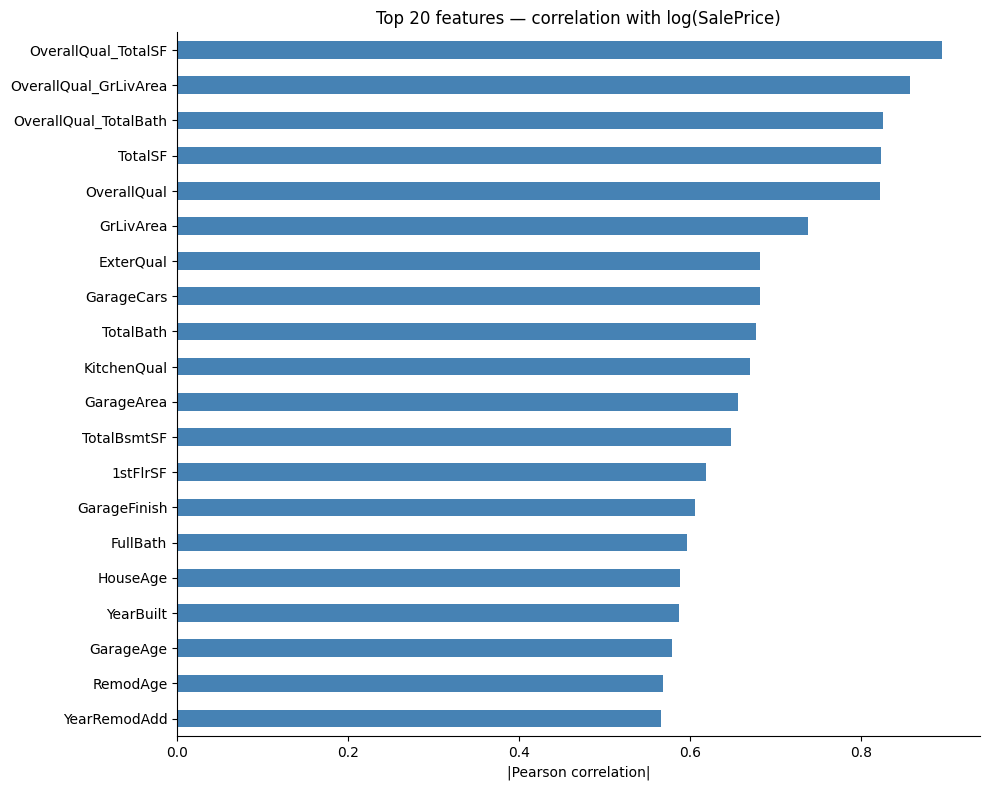

In [24]:
# Correlation of new features with the target variable
feature_corr = X_train.corrwith(y).abs().sort_values(ascending=False)

print('Top 20 features based on correlation with log(SalePrice):')
print(feature_corr.head(20).round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
feature_corr.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 features — correlation with log(SalePrice)')
ax.set_xlabel('|Pearson correlation|')
plt.tight_layout()
plt.show()

In [25]:
os.makedirs('data/processed', exist_ok=True)

X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv',   index=False)
y.to_csv('data/processed/y_train.csv',        index=False, header=['SalePrice_log'])

# Save the list of attributes for use in app.py
feature_names = X_train.columns.tolist()
pd.Series(feature_names).to_csv('data/processed/feature_names.csv', index=False, header=['feature'])

print('Files saved in data/processed/')
print(f'   X_train.csv      — {X_train.shape}')
print(f'   X_test.csv       — {X_test.shape}')
print(f'   y_train.csv      — {y.shape}')
print(f'   feature_names.csv — {len(feature_names)} features')

Files saved in data/processed/
   X_train.csv      — (1458, 94)
   X_test.csv       — (1459, 94)
   y_train.csv      — (1458,)
   feature_names.csv — 94 features


In [26]:
print('=' * 60)
print('CONCLUSION OF FEATURE ENGINEERING')
print('=' * 60)
print(f'''
Original features:    {train.shape[1] + 1} (including SalePrice)
After processing:      {X_train.shape[1]} features
New features:           {len(new_features)}
Removed:              Utilities (constant), Id, SalePrice
Outliers removed:      2 records (GrLivArea > 4000 and SalePrice < 300k)
Target variable:   log1p(SalePrice) → back to expm1() after prediction

→ Next step: 03_modeling.ipynb
''')

CONCLUSION OF FEATURE ENGINEERING

Original features:    80 (including SalePrice)
After processing:      94 features
New features:           16
Removed:              Utilities (constant), Id, SalePrice
Outliers removed:      2 records (GrLivArea > 4000 and SalePrice < 300k)
Target variable:   log1p(SalePrice) → back to expm1() after prediction

→ Next step: 03_modeling.ipynb



In [28]:
from scipy.special import boxcox1p
from scipy.stats import skew
import joblib

preprocessing_config = {
    'skewed_feats': skewed_feats,   
    'box_cox_lambda': 0.15,
    'ordinal_maps': ordinal_maps,   
    'none_cols': none_cols,
    'zero_cols': zero_cols,
    'cat_as_str': cat_as_str,
    'train_medians': all_data.iloc[:ntrain].median().to_dict(),  
}

joblib.dump(preprocessing_config, 'models/preprocessing_config.pkl')
print('preprocessing_config.pkl saved')

preprocessing_config.pkl saved
